In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

In [2]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

In [10]:
output_paths = list(Path('swc_mono_eval').glob('**/*.pkl'))
# output_paths

In [11]:
output_paths

[PosixPath('swc_mono_eval/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor_1-talker_-3_eval_results.pkl'),
 PosixPath('swc_mono_eval/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor_1-talker_-6_eval_results.pkl'),
 PosixPath('swc_mono_eval/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor_1-talker_-9_eval_results.pkl'),
 PosixPath('swc_mono_eval/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor_1-talker_0_eval_results.pkl'),
 PosixPath('swc_mono_eval/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor_1-talker_3_eval_results.pkl'),
 PosixPath('swc_mono_eval/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_d

In [12]:
# path.stem.split(path.parent.name)[-1].split('_')[-3]

In [22]:
path

PosixPath('swc_mono_eval/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor_background_musdb18hq_3_eval_results.pkl')

In [25]:
results_dfs = []
for path in output_paths:
    res_dict = pickle.load(open(path, 'rb'))
    # reformat dict
    record = {}
    record['accuracy'] = res_dict['acc']
    record['std_error'] = res_dict['std_err']
    record['model'] = path.parent.name
    #parts of name 
    parts = path.stem.split(path.parent.name)[-1].split('_')       
    if "background" in path.stem:
        record['condition'] = parts[2]
    else:
        record['condition'] = parts[1]
    if 'SILENCE' in path.stem:
        record['snr'] = np.inf
    else:
        record['snr'] = int(parts[-3])

    df = pd.DataFrame.from_records([record])
    results_dfs.append(df)
results = pd.concat(results_dfs)

(0.0, 1.0)

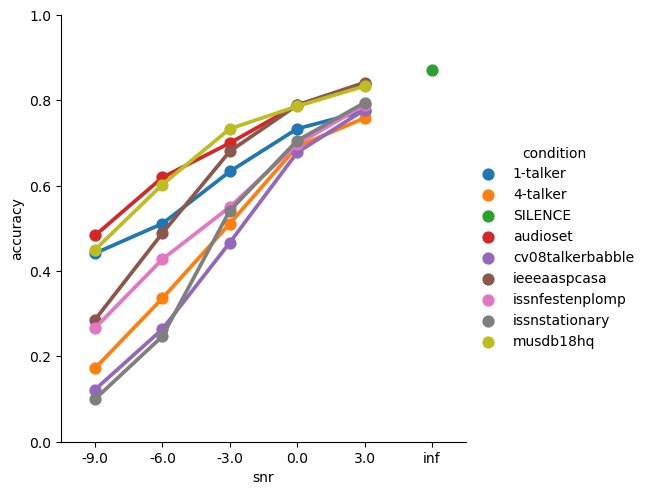

In [30]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]

hue_order = ['SILENCE', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))
sns.catplot(data=results, x='snr', y='accuracy', hue='condition', kind='point')
plt.ylim(0,1)

In [26]:
results

,accuracy,std_error,model,condition,snr
0,0.633333,0.025433,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,1-talker,-3.0
0,0.511111,0.026382,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,1-talker,-6.0
0,0.441667,0.026209,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,1-talker,-9.0
0,0.733333,0.023339,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,1-talker,0.0
0,0.775000,0.022039,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,1-talker,3.0
0,0.511111,0.026382,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,4-talker,-3.0
0,0.336111,0.024931,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,4-talker,-6.0
0,0.172222,0.019928,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,4-talker,-9.0
0,0.691667,0.024373,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,4-talker,0.0
0,0.758333,0.022594,attn_cue_lr_1e-4_bs_64_constrained_slope_multi...,4-talker,3.0


In [16]:
# replace inf in snr with 6 
combined['snr'] = combined['snr'].replace(np.inf, 6)

# replace ieee with natural scene
combined['condition'] = combined['condition'].replace('ieee', 'natural scene')
combined.model.unique()



array(['attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor',
       'human'], dtype=object)

Text(0.5, 1.0, 'Human')

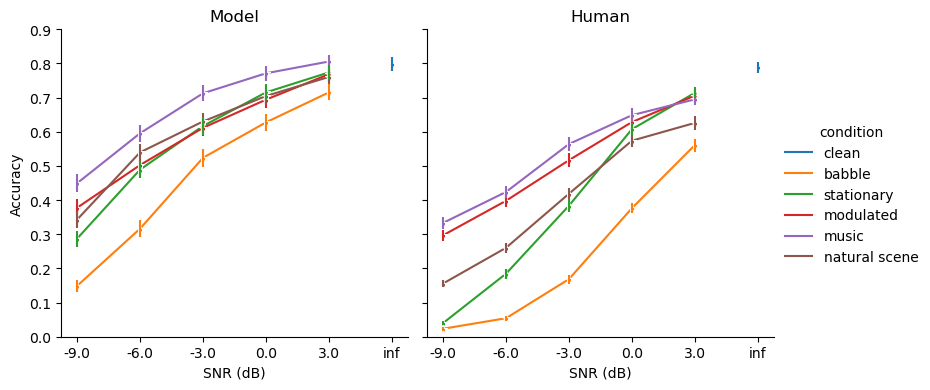

In [19]:
to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', ]

palette = dict(zip(hue_order, sns.color_palette(n_colors=len(hue_order)+2, as_cmap=True)))

# add markers to relplot
# plt.figure(figsize=(2,2))
g = sns.relplot(data=to_plot, x='snr', y='accuracy', hue='condition', hue_order=hue_order, col="model",
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='*', palette=palette, height=4, aspect=1)
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')


# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # select the data for the facet
    data = to_plot[to_plot['model'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="accuracy", yerr="std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,.9)
g.axes.flat[0].set_ylabel('Accuracy')
g.axes.flat[1].set_ylabel('')
g.axes.flat[0].set_xlabel('SNR (dB)')
g.axes.flat[1].set_xlabel('SNR (dB)')
g.axes.flat[0].set_title('Model')
g.axes.flat[1].set_title('Human')


# plt.tight_layout()

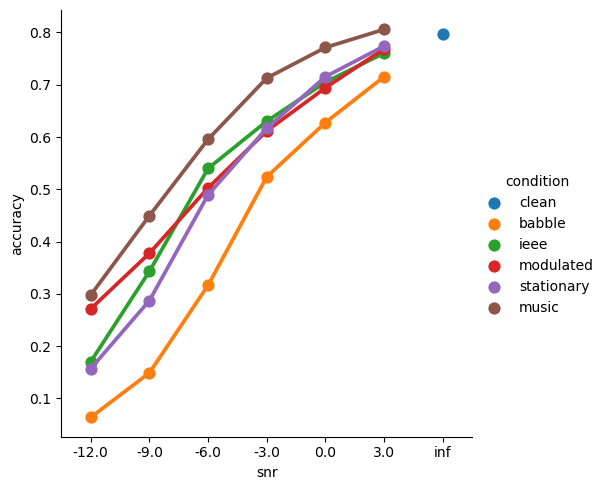

In [51]:
hue_order_model = ['clean', 'babble', 'ieee', 'modulated', 'stationary', 'music']
sns.catplot(data=results[results.condition != 'audioset'], x='snr', y='accuracy', hue='condition', hue_order=hue_order_model, kind='point')